# Route display
This is the first setup to display a route on a map.

In [21]:
%pip install ortools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

In [23]:
grid_size = 100
num_dots = 10
grid = np.zeros((grid_size, grid_size))
np.random.seed(42)  

dots = [(np.random.randint(0, grid_size), np.random.randint(0, grid_size)) for _ in range(num_dots)]

In [24]:
dots

[(51, 92),
 (14, 71),
 (60, 20),
 (82, 86),
 (74, 74),
 (87, 99),
 (23, 2),
 (21, 52),
 (1, 87),
 (29, 37)]

In [25]:
connections = []
for i in range(len(dots) - 1):
    connections.append((dots[i], dots[i + 1]))

print(connections)

[((51, 92), (14, 71)), ((14, 71), (60, 20)), ((60, 20), (82, 86)), ((82, 86), (74, 74)), ((74, 74), (87, 99)), ((87, 99), (23, 2)), ((23, 2), (21, 52)), ((21, 52), (1, 87)), ((1, 87), (29, 37))]


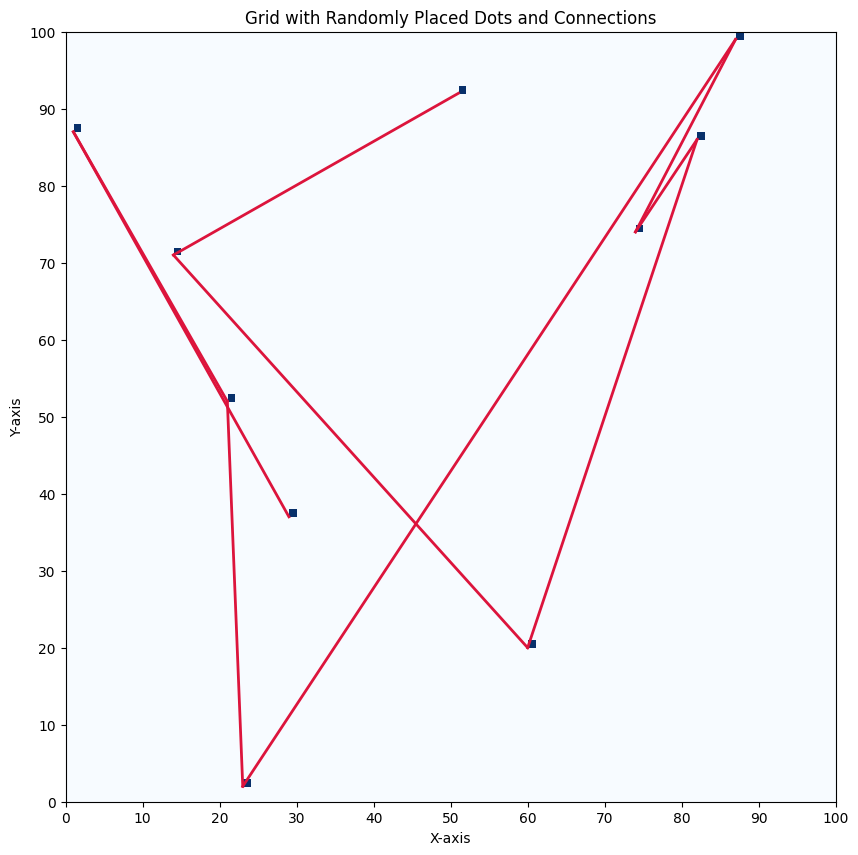

In [26]:
grid = np.zeros((grid_size, grid_size))

for dot in dots:
    x, y = dot
    grid[y, x] = 1

plt.figure(figsize=(10, 10))
plt.imshow(
    grid,
    cmap='Blues',
    origin='lower',
    extent=[0, 100, 0, 100],
    interpolation='nearest',
    aspect='equal'
)

for (x1, y1), (x2, y2) in connections:
    plt.plot([x1, x2], [y1, y2], color='crimson', linewidth=2)

ticks = np.arange(0, 101, 10)
plt.xticks(ticks)
plt.yticks(ticks)
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.title('Grid with Randomly Placed Dots and Connections')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [27]:
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

n = len(dots)
distance_matrix = [
    [int(euclidean_distance(dots[i], dots[j]) * 1000) for j in range(n)]
    for i in range(n)
]

print(f"Distance matrix built for {n} dots")

Distance matrix built for 10 dots


In [ ]:
try:
    from ortools.constraint_solver import routing_enums_pb2, pywrapcp

    manager = pywrapcp.RoutingIndexManager(n, 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    transit_idx = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(5)

    solution = routing.SolveWithParameters(params)
    index = routing.Start(0)
    optimal_route = []
    while not routing.IsEnd(index):
        optimal_route.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    optimal_route.append(optimal_route[0])
    total_dist = solution.ObjectiveValue() / 1000
    solver_used = "Google OR-Tools"

except ImportError:
    print("OR-Tools not found — using nearest-neighbour fallback.")
    print("Install with: pip install ortools")
    visited = [False] * n
    optimal_route = [0]
    visited[0] = True
    for _ in range(n - 1):
        current = optimal_route[-1]
        nearest = min(
            (j for j in range(n) if not visited[j]),
            key=lambda j: distance_matrix[current][j]
        )
        optimal_route.append(nearest)
        visited[nearest] = True
    optimal_route.append(0)
    total_dist = sum(
        distance_matrix[optimal_route[i]][optimal_route[i+1]]
        for i in range(len(optimal_route) - 1)
    ) / 1000
    solver_used = "Nearest-Neighbour Heuristic (fallback)"

print(f"Solver      : {solver_used}")
print(f"Route order : {optimal_route}")
print(f"Total dist  : {total_dist:.2f} units")

Solver      : Google OR-Tools
Route order : [0, 5, 3, 4, 2, 6, 9, 7, 1, 8, 0]
Total dist  : 305.58 units

Step-by-step route:
  Step 1: dot 0 → (51, 92)
  Step 2: dot 5 → (87, 99)
  Step 3: dot 3 → (82, 86)
  Step 4: dot 4 → (74, 74)
  Step 5: dot 2 → (60, 20)
  Step 6: dot 6 → (23, 2)
  Step 7: dot 9 → (29, 37)
  Step 8: dot 7 → (21, 52)
  Step 9: dot 1 → (14, 71)
  Step 10: dot 8 → (1, 87)
  Step 11: dot 0 → (51, 92)  ← back to start


In [29]:
original_route = list(range(num_dots)) + [0]
original_dist = sum(
    euclidean_distance(dots[original_route[i]], dots[original_route[i+1]])
    for i in range(len(original_route) - 1)
)

improvement = (1 - total_dist / original_dist) * 100
print(f"Original distance : {original_dist:.2f} units")
print(f"Optimal distance  : {total_dist:.2f} units")
print(f"Improvement       : {improvement:.1f}% shorter")

Original distance : 546.50 units
Optimal distance  : 305.58 units
Improvement       : 44.1% shorter


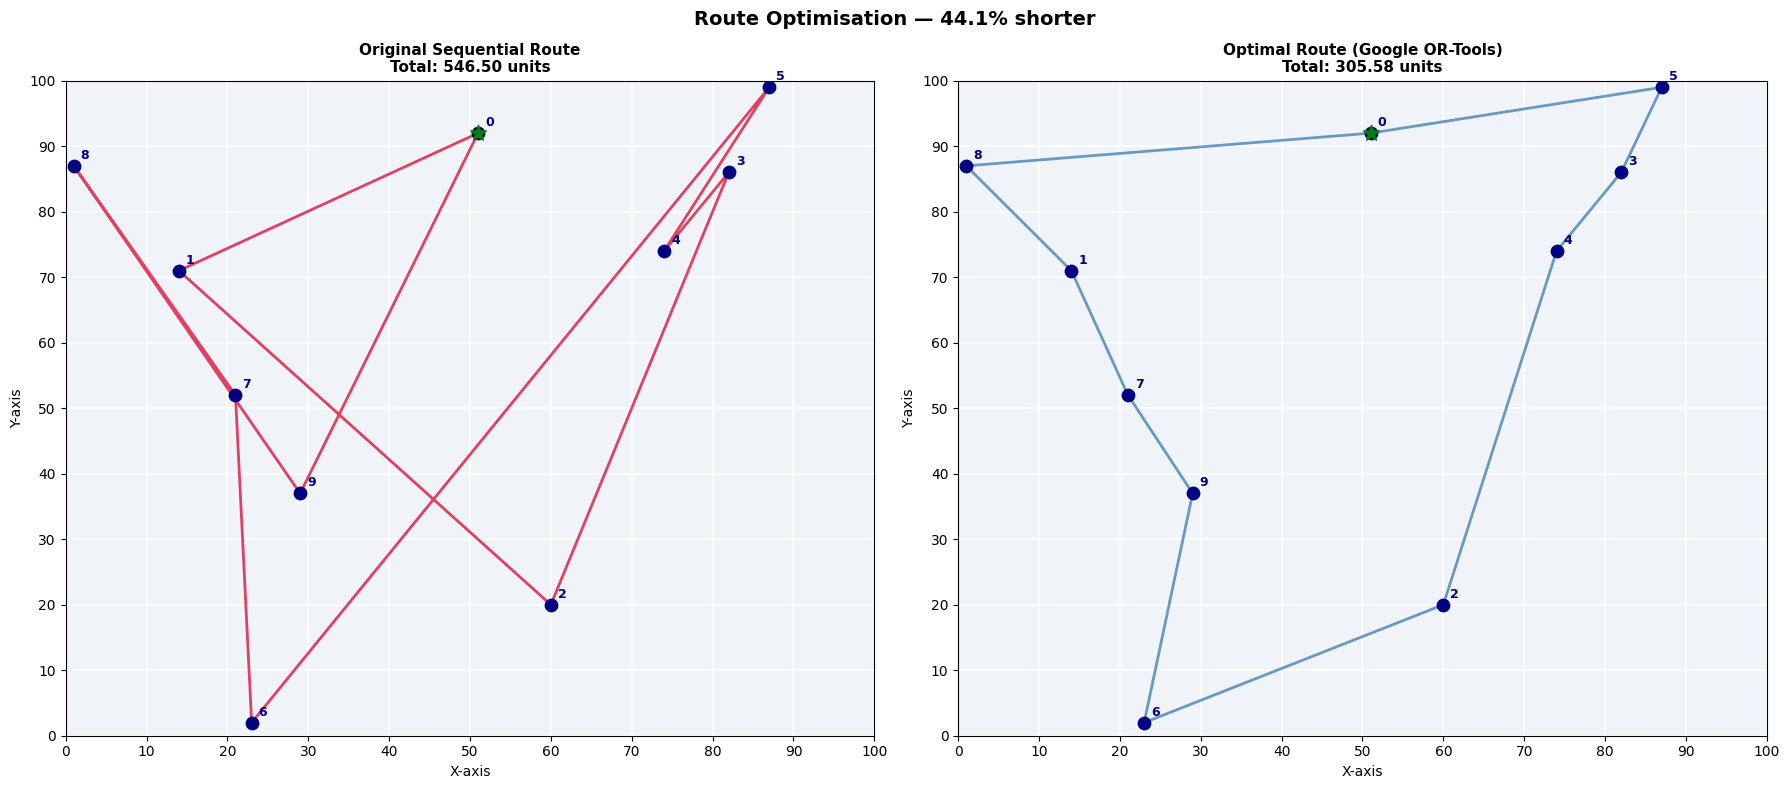

In [30]:
def draw_route(ax, dots, route, title, line_color, dist):
    ax.set_facecolor('#f0f4f8')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ticks = np.arange(0, 101, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.grid(True, color='white', linewidth=1.2)

    xs = [dots[i][0] for i in route]
    ys = [dots[i][1] for i in route]
    ax.plot(xs, ys, color=line_color, linewidth=2, alpha=0.8)

    for idx, (x, y) in enumerate(dots):
        ax.scatter(x, y, color='navy', s=80, zorder=3)
        ax.annotate(str(idx), (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=9,
                    color='navy', fontweight='bold')

    ax.scatter(*dots[route[0]], color='green', s=140, zorder=4, marker='*')
    ax.set_title(f"{title}\nTotal: {dist:.2f} units", fontsize=11, fontweight='bold')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

draw_route(ax1, dots, original_route, 'Original Sequential Route', 'crimson', original_dist)
draw_route(ax2, dots, optimal_route, f'Optimal Route ({solver_used})', 'steelblue', total_dist)

plt.suptitle(f'Route Optimisation — {improvement:.1f}% shorter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()